# 05 — Evaluation

Goal: deep-dive into the best model's performance with **PR-AUC as the headline metric**, plus threshold tuning, feature importance, and SHAP-based interpretability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import shap
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score, f1_score
)

sns.set_theme(style='whitegrid')
%matplotlib inline

REPORT_DIR = '../results/05_evaluation'
os.makedirs(REPORT_DIR, exist_ok=True)

## 1. Load Model, Metadata, and Test Data

The metadata from `04_modeling.ipynb` tells us which feature set (`full` or `selected`) the winning model was trained on, so we load the matching CSVs.

In [2]:
with open('../models/best_model_metadata.json') as f:
    metadata = json.load(f)

feature_set = metadata['feature_set']
print(f"Best model: {metadata['model']} | strategy: {metadata['imbalance_strategy']} | feature_set: {feature_set}")
print(f"Val PR-AUC (model selection): {metadata['val_prauc']:.4f}")
print(f"Features used ({len(metadata['features'])}): {metadata['features']}")

model = joblib.load('../models/best_model.pkl')

# Test set is loaded here for the FIRST and ONLY time — never used in 04_modeling
train = pd.read_csv(f'../data/processed/train_{feature_set}.csv')
test  = pd.read_csv(f'../data/processed/test_{feature_set}.csv')

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_test  = test.drop(columns=['Class'])
y_test  = test['Class']

y_prob = model.predict_proba(X_test)[:, 1]

test_prauc  = average_precision_score(y_test, y_prob)
test_rocauc = roc_auc_score(y_test, y_prob)
print(f'\nTest PR-AUC : {test_prauc:.4f}')
print(f'Test ROC-AUC: {test_rocauc:.4f}')

Best model: xgboost | strategy: random_over | feature_set: selected
Val PR-AUC (model selection): 0.8251
Features used (28): ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27', 'V28', 'V24', 'V13', 'V26', 'V15', 'V25', 'V23', 'V22']



Test PR-AUC : 0.8675
Test ROC-AUC: 0.9723


## 2. Precision-Recall Curve (Headline Metric)

PR-AUC is the primary evaluation metric for this project — accuracy and ROC-AUC are both misleadingly optimistic under ~0.17% fraud prevalence.

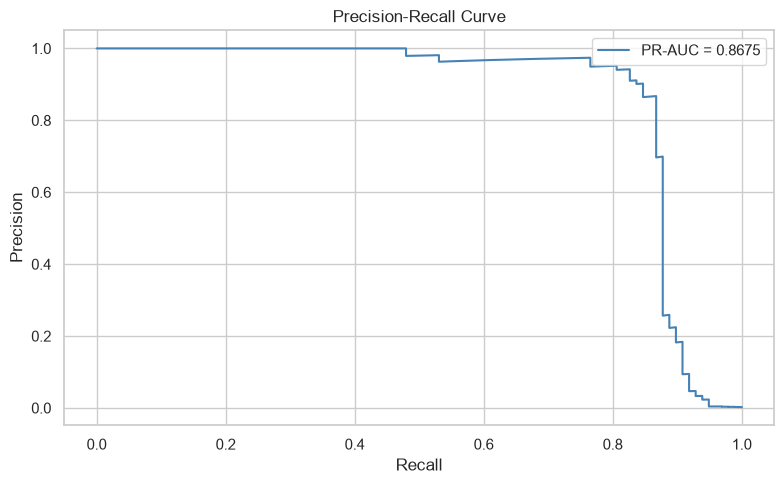

In [3]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
prauc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'PR-AUC = {prauc:.4f}', color='steelblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/pr_curve.png', dpi=150)
plt.show()

## 3. ROC Curve

Shown for completeness. Note that ROC-AUC is **misleadingly optimistic** for this dataset: with ~56k legitimate transactions in the test set, the False Positive Rate denominator (FP + TN) is so large that FPR stays very low even with many false alarms, making the ROC curve look excellent. PR-AUC is a stricter and more honest metric for imbalanced fraud detection.

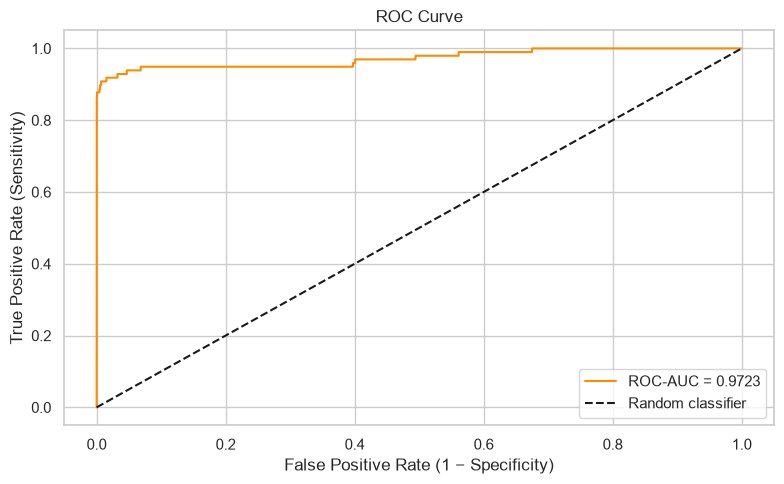

In [4]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate (1 − Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/roc_curve.png', dpi=150)
plt.show()

## 4. Threshold Tuning

Find the threshold that maximises F1-score on the test set.

Best threshold: 0.7811
Best F1:        0.8804


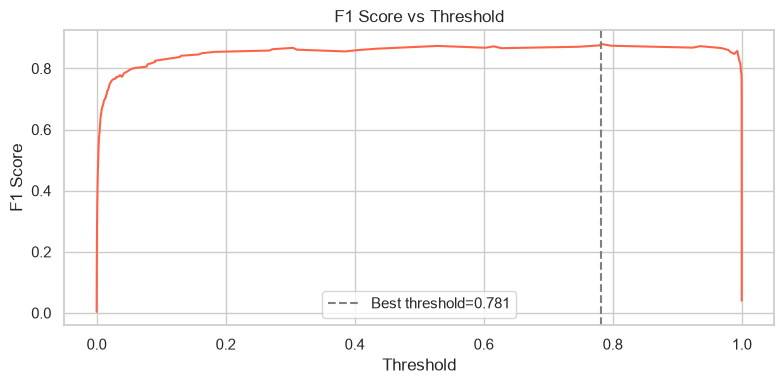

In [5]:
f1_scores = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Best threshold: {best_threshold:.4f}')
print(f'Best F1:        {best_f1:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='tomato')
plt.axvline(best_threshold, linestyle='--', color='gray', label=f'Best threshold={best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/threshold_tuning.png', dpi=150)
plt.show()

## 5. Confusion Matrix and Classification Metrics (Best Threshold)

Shown once at the F1-optimal threshold. PR-AUC above remains the primary metric for model selection.

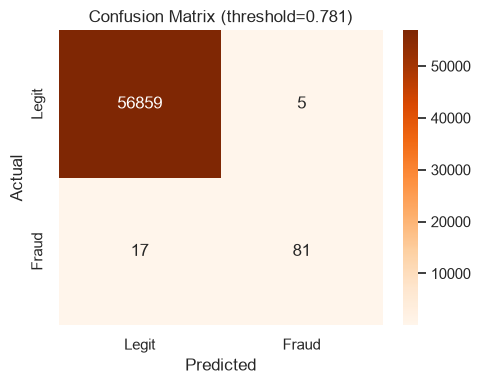

TP=81  FP=5  FN=17  TN=56859


Metric,Value
Accuracy,0.9996
F1-Score,0.8804
Recall (Sensitivity),0.8265
Specificity,0.9999
PPV (Precision),0.9419
NPV,0.9997
Youden's Index,0.8264


In [6]:
y_pred_best = (y_prob >= best_threshold).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion Matrix (threshold={best_threshold:.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

TN, FP, FN, TP = cm_best.ravel()
sensitivity  = TP / (TP + FN)
specificity  = TN / (TN + FP)
ppv          = TP / (TP + FP) if (TP + FP) > 0 else 0.0
npv          = TN / (TN + FN) if (TN + FN) > 0 else 0.0
accuracy     = (TP + TN) / (TP + TN + FP + FN)
f1           = 2 * ppv * sensitivity / (ppv + sensitivity) if (ppv + sensitivity) > 0 else 0.0
youden_index = sensitivity + specificity - 1

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Recall (Sensitivity)', 'Specificity',
               'PPV (Precision)', 'NPV', "Youden's Index"],
    'Value':  [accuracy, f1, sensitivity, specificity, ppv, npv, youden_index],
})
metrics_df['Value'] = metrics_df['Value'].map('{:.4f}'.format)
metrics_df.to_csv(f'{REPORT_DIR}/classification_metrics.csv', index=False)

print(f'TP={TP}  FP={FP}  FN={FN}  TN={TN}')
display(metrics_df.style.hide(axis='index'))

## 6. Feature Importance

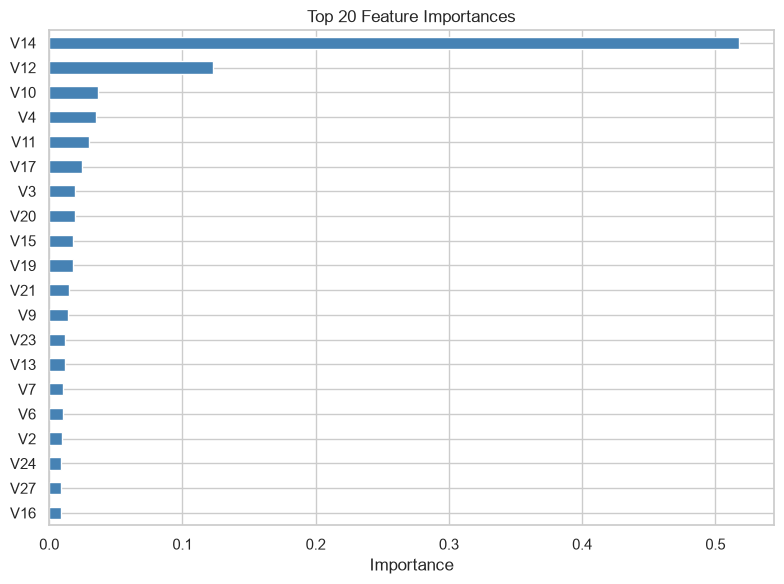

In [7]:
fitted_clf = model.named_steps['clf'] if hasattr(model, 'named_steps') else model

if hasattr(fitted_clf, 'feature_importances_'):
    importances = pd.Series(fitted_clf.feature_importances_, index=X_test.columns)
    importances = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(8, 6))
    importances.plot(kind='barh', color='steelblue')
    plt.title('Top 20 Feature Importances')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/feature_importance.png', dpi=150)
    plt.show()
else:
    # Logistic Regression: use absolute coefficient values
    coef = pd.Series(np.abs(fitted_clf.coef_[0]), index=X_test.columns)
    coef = coef.sort_values(ascending=False).head(20)

    plt.figure(figsize=(8, 6))
    coef.plot(kind='barh', color='steelblue')
    plt.title('Top 20 Feature Coefficients (|coef|)')
    plt.xlabel('|Coefficient|')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/feature_importance.png', dpi=150)
    plt.show()

## 7. SHAP Analysis

Local and global interpretability for the winning model. `shap.TreeExplainer` computes exact SHAP values for tree-based models — no background sample needed, no approximation warning.

In [8]:
N_EXPLAIN = 500

fitted_clf = model.named_steps['clf'] if hasattr(model, 'named_steps') else model

# Stratify the explained sample so it always contains fraud cases — at ~0.17%
# fraud prevalence, a pure random draw of 500 rows would average <1 fraud case,
# which would silently break the waterfall plots below.
fraud_rows = X_test[y_test == 1]
n_legit = max(N_EXPLAIN - len(fraud_rows), 0)
legit_rows = X_test[y_test == 0].sample(n=min(n_legit, (y_test == 0).sum()), random_state=42)
explain_sample = pd.concat([fraud_rows, legit_rows]).sample(frac=1, random_state=42)

if hasattr(fitted_clf, 'feature_importances_'):
    # Tree-based model: exact SHAP values, no background sample needed
    explainer = shap.TreeExplainer(fitted_clf)
else:
    # Logistic Regression: use LinearExplainer with a background sample
    background = X_train.sample(n=300, random_state=42)
    explainer = shap.LinearExplainer(fitted_clf, background)

shap_values = explainer(explain_sample)

# LightGBM / RandomForest binary classification may return shape (n, f, 2) — keep positive class
if shap_values.values.ndim == 3:
    shap_values = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=(shap_values.base_values[:, 1]
                     if shap_values.base_values.ndim > 1
                     else shap_values.base_values),
        data=shap_values.data,
        feature_names=shap_values.feature_names,
    )

print(f'SHAP values shape: {shap_values.values.shape}')

SHAP values shape: (500, 28)


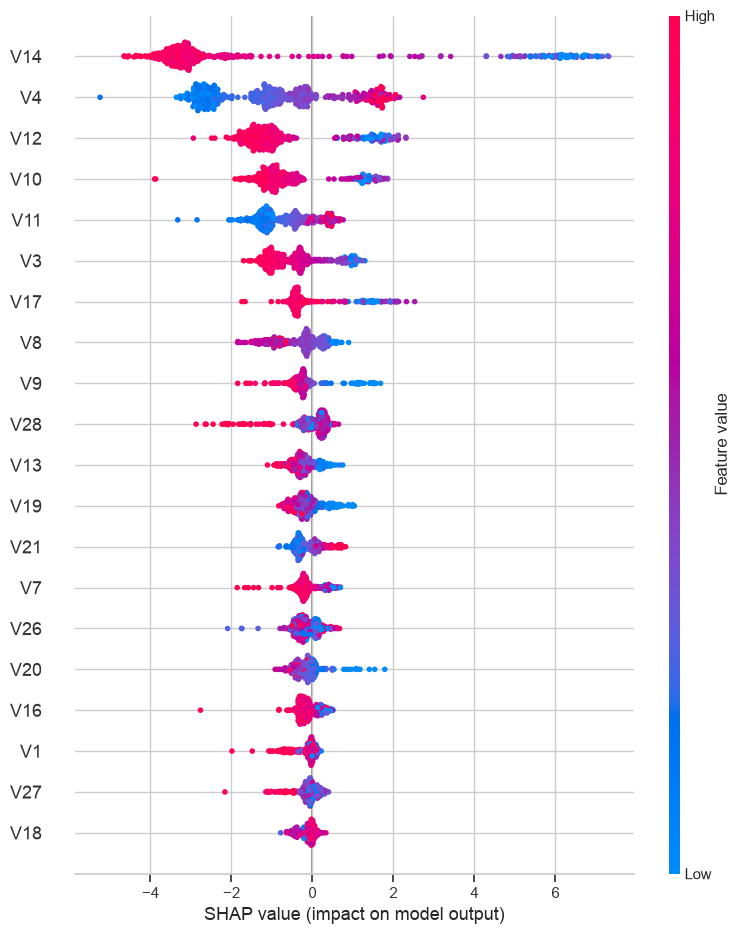

In [9]:
plt.figure()
shap.summary_plot(shap_values, explain_sample, show=False)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

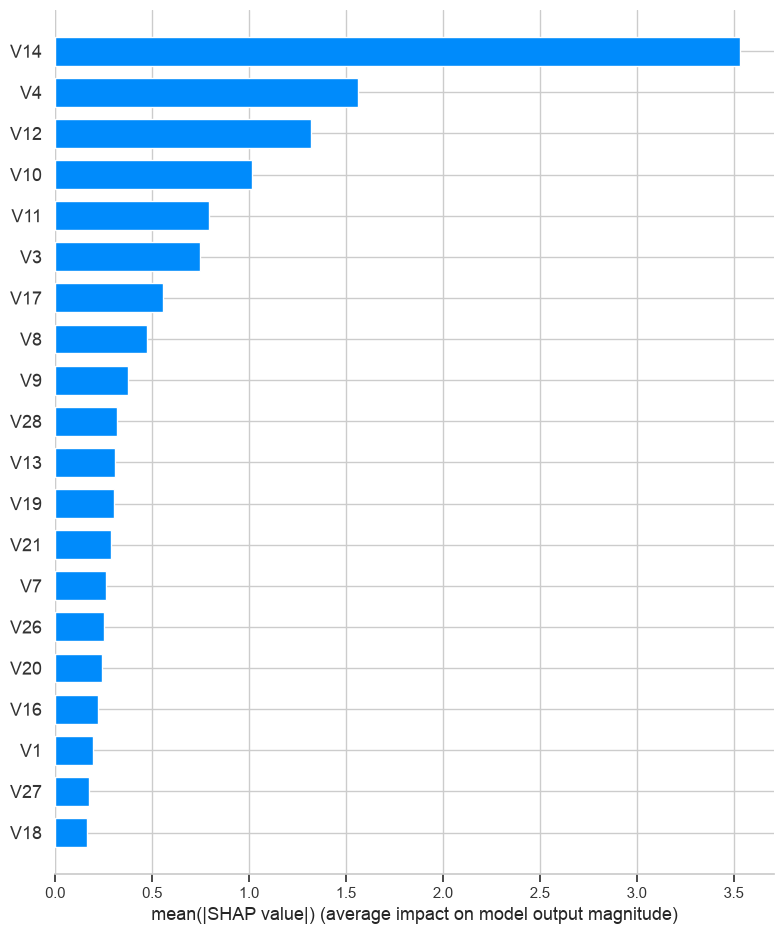

In [10]:
plt.figure()
shap.summary_plot(shap_values, explain_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Top 3 features by mean |SHAP value|: ['V14', 'V4', 'V12']


<Figure size 640x480 with 0 Axes>

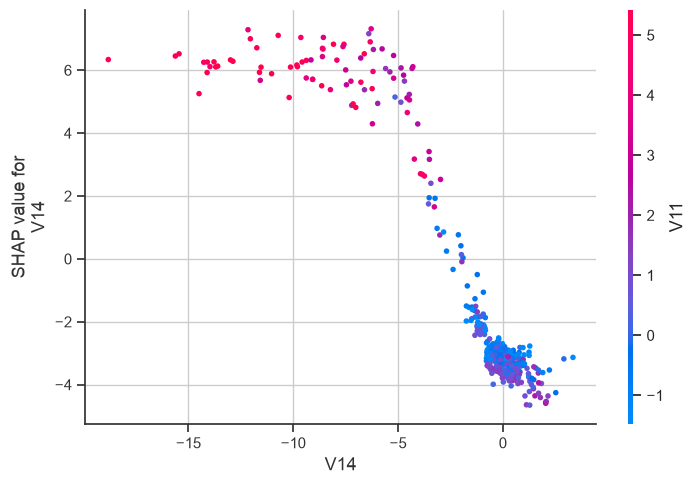

<Figure size 640x480 with 0 Axes>

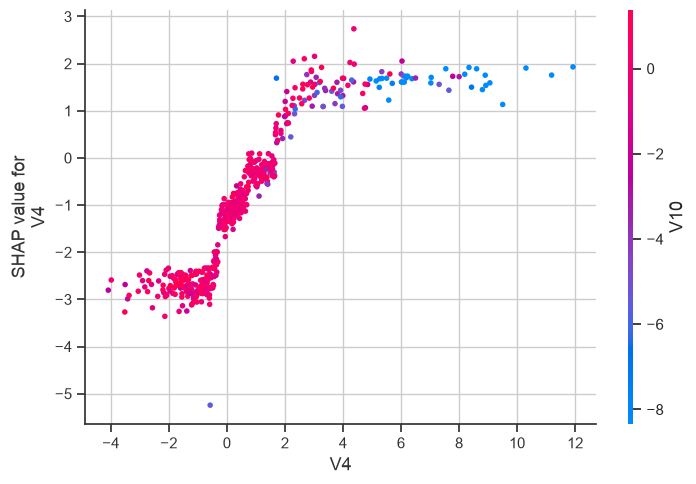

<Figure size 640x480 with 0 Axes>

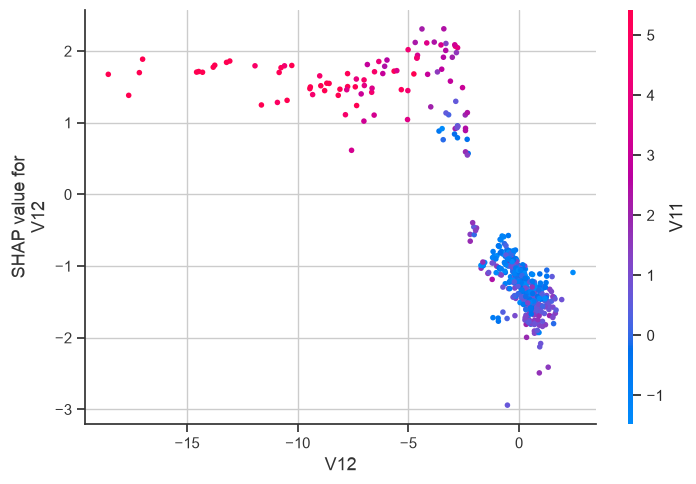

In [11]:
mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=explain_sample.columns)
top3_features = mean_abs_shap.sort_values(ascending=False).index[:3].tolist()
print(f'Top 3 features by mean |SHAP value|: {top3_features}')

for feat in top3_features:
    plt.figure()
    shap.dependence_plot(feat, shap_values.values, explain_sample, show=False)
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/shap_dependence_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Local Explanations: a Caught Fraud vs. a Missed Fraud

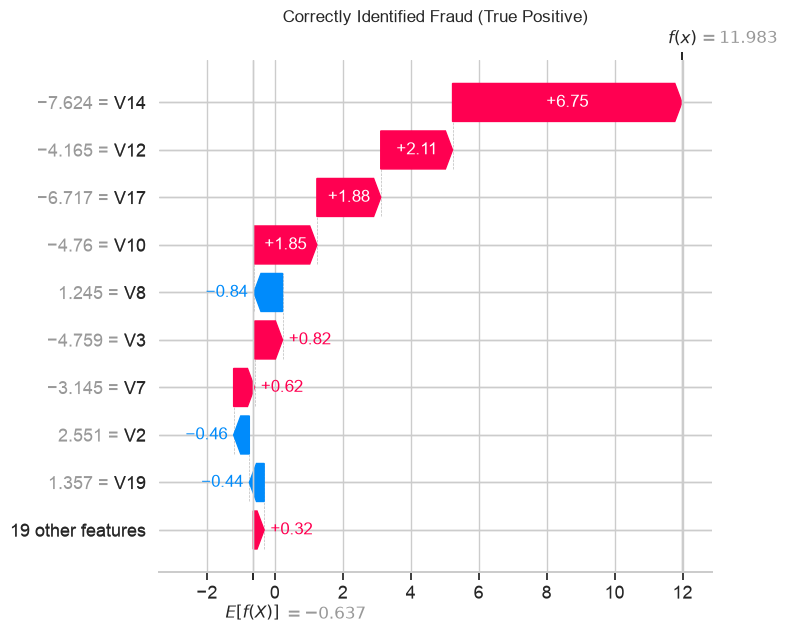

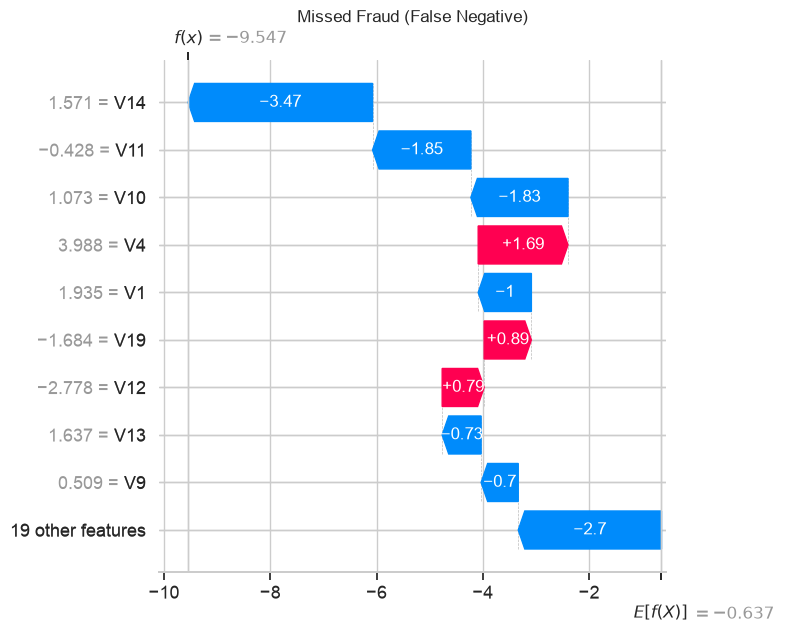

In [12]:
y_explain = y_test.loc[explain_sample.index]
prob_explain = fitted_clf.predict_proba(explain_sample)[:, 1]
pred_explain = (prob_explain >= best_threshold).astype(int)

true_positive_idx = explain_sample.index[(y_explain == 1) & (pred_explain == 1)]
false_negative_idx = explain_sample.index[(y_explain == 1) & (pred_explain == 0)]

if len(true_positive_idx) > 0:
    pos = explain_sample.index.get_loc(true_positive_idx[0])
    shap.plots.waterfall(shap_values[pos], show=False)
    plt.title('Correctly Identified Fraud (True Positive)')
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/shap_waterfall_true_positive.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No true positive fraud case found in the explained sample.')

if len(false_negative_idx) > 0:
    pos = explain_sample.index.get_loc(false_negative_idx[0])
    shap.plots.waterfall(shap_values[pos], show=False)
    plt.title('Missed Fraud (False Negative)')
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/shap_waterfall_false_negative.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No false negative fraud case found in the explained sample.')